/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv
/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv

Starting Titanic Solution...
Loading Train: /kaggle/input/competitions/titanic/train.csv
Loading Test: /kaggle/input/competitions/titanic/test.csv

Generating Visualizations...


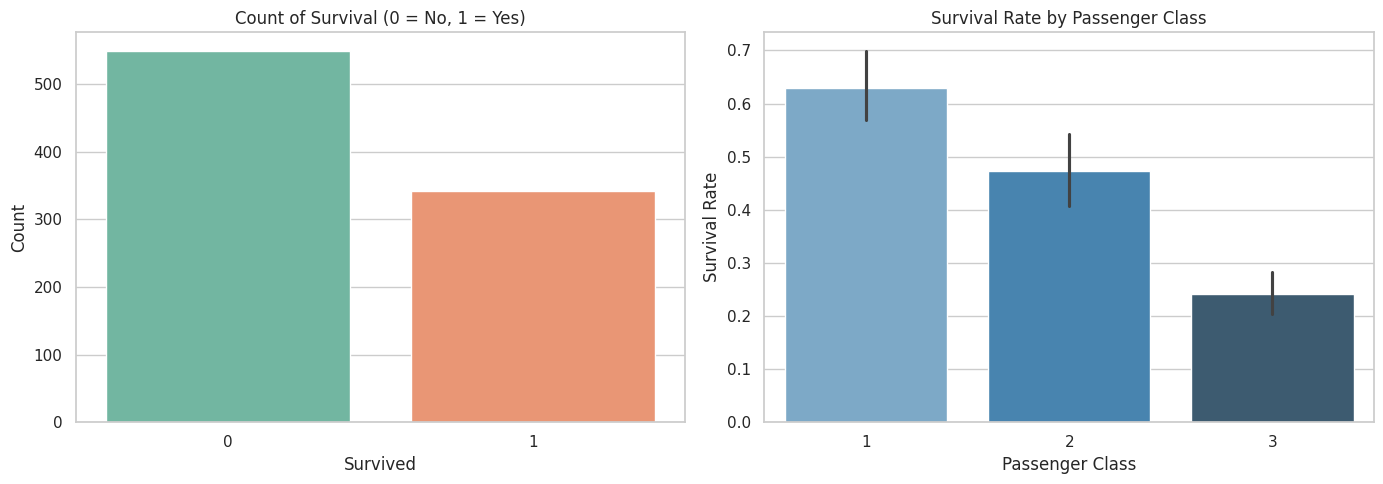


--- Quick Insights ---
Overall Survival Rate: 38.38%
Survival by Class:
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363

Training Random Forest Model...
Predicting on Test Set...
Submission saved successfully to /kaggle/working/submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         1


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import numpy as np 
import pandas as pd 
import warnings
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.ensemble import RandomForestClassifier

# Set visualization style
sns.set(style="whitegrid")

# Ignore warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# ---------------------------------------------------------
# SOLUTION Method body
# ---------------------------------------------------------

def main():
    print("\nStarting Titanic Solution...")

    # 1. Load Data
    train_path = None
    test_path = None
    
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename == 'train.csv': train_path = os.path.join(dirname, filename)
            if filename == 'test.csv': test_path = os.path.join(dirname, filename)

    if not train_path or not test_path:
        print("Error: Could not find train.csv or test.csv in /kaggle/input")
        return

    print(f"Loading Train: {train_path}")
    print(f"Loading Test: {test_path}")
    
    train_df = pd.read_csv(train_path)
    # FIXED: Changed pd.read_csv(test_df) to pd.read_csv(test_path)
    test_df = pd.read_csv(test_path)

    # ---------------------------------------------------------
    # 2. EXPLORATORY DATA ANALYSIS (BAR CHARTS)
    # ---------------------------------------------------------
    print("\nGenerating Visualizations...")
    
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Chart 1: Count of Survived vs Not Survived
    sns.countplot(x='Survived', data=train_df, ax=axes[0], palette="Set2")
    axes[0].set_title('Count of Survival (0 = No, 1 = Yes)')
    axes[0].set_xlabel('Survived')
    axes[0].set_ylabel('Count')

    # Chart 2: Survival Rate by Passenger Class (Pclass)
    # The barplot automatically calculates the mean (probability) of survival
    sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[1], palette="Blues_d")
    axes[1].set_title('Survival Rate by Passenger Class')
    axes[1].set_xlabel('Passenger Class')
    axes[1].set_ylabel('Survival Rate')

    plt.tight_layout()
    plt.show()
    
    # Print some quick insights
    print("\n--- Quick Insights ---")
    print(f"Overall Survival Rate: {train_df['Survived'].mean():.2%}")
    print("Survival by Class:")
    print(train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False))

    # ---------------------------------------------------------
    # 3. Feature Engineering
    # ---------------------------------------------------------
    
    # Combine data for consistent feature engineering
    combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
    
    # Feature: Title (Extract from Name)
    # Use raw string r'...' to fix SyntaxWarning
    combined['Title'] = combined.Name.str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles
    combined['Title'] = combined['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
        'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    combined['Title'] = combined['Title'].replace('Mlle', 'Miss')
    combined['Title'] = combined['Title'].replace('Ms', 'Miss')
    combined['Title'] = combined['Title'].replace('Mme', 'Mrs')
    
    # Feature: FamilySize & IsAlone
    combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
    combined['IsAlone'] = 0
    combined.loc[combined['FamilySize'] == 1, 'IsAlone'] = 1

    # 4. Handling Missing Data
    
    # Age: Fill missing with median age of the Title group
    combined['Age'] = combined.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
    
    # Embarked: Fill missing with mode
    combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])
    
    # Fare: Fill missing with median
    combined['Fare'] = combined['Fare'].fillna(combined['Fare'].median())

    # 5. Encoding Categorical Variables
    
    # Sex: male=0, female=1
    combined['Sex'] = combined['Sex'].map({'male': 0, 'female': 1})
    
    # Title Mapping
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    combined['Title'] = combined['Title'].map(title_mapping)
    combined['Title'] = combined['Title'].fillna(0)
    
    # Embarked Mapping
    embarked_mapping = {"S": 0, "C": 1, "Q": 2}
    combined['Embarked'] = combined['Embarked'].map(embarked_mapping)

    # 6. Preparing Final Dataset
    drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
    data = combined.drop(drop_cols, axis=1)

    # Split back into Train and Test
    train_len = len(train_df)
    train_data = data[:train_len]
    test_data = data[train_len:]

    # Define X and y
    X_train = train_data.drop("Survived", axis=1)
    y_train = train_data["Survived"]
    X_test = test_data.drop("Survived", axis=1)

    # 7. Model Training
    print("\nTraining Random Forest Model...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 8. Prediction
    print("Predicting on Test Set...")
    predictions = model.predict(X_test)

    # 9. Submission File Creation
    submission = pd.DataFrame({
        "PassengerId": test_df['PassengerId'],
        "Survived": predictions
    })
    
    # Ensure integer format
    submission['Survived'] = submission['Survived'].astype(int)

    submission_path = '/kaggle/working/submission.csv'
    submission.to_csv(submission_path, index=False)
    
    print(f"Submission saved successfully to {submission_path}")
    print(submission.head())

if __name__ == "__main__":
    main()